In [309]:
import pandas as pd 
import numpy as np
import joblib 
import matplotlib.pyplot as plt

In [310]:
# Load data
df = pd.read_excel("../data/data2.xlsx")
df.head()

,Cube_ID,Mix_ID,Steel_Fibre_%,Cement_kg_m3,Sand_kg_m3,Water_kg_m3,SilicaFume_kg_m3,Cube_Size,Age_Days,Curing_Method,Failure_Load_kN,Compressive_Strength_MPa
0,1,UHPC-4,1.5,880,1035,168,190,100x100x100 mm,28,Ambient Curing,1798.7,179.87
1,2,UHPC-2,0.5,840,1065,172,170,100x100x100 mm,28,Steam Curing,1734.3,173.43
2,3,UHPC-1,0.0,820,1080,175,160,100x100x100 mm,28,Heat Curing,1807.1,180.71
3,4,UHPC-4,1.5,880,1035,168,190,100x100x100 mm,28,Heat Curing,2024.2,202.42
4,5,UHPC-3,1.0,860,1050,170,180,100x100x100 mm,56,Steam Curing,2001.7,200.17


In [311]:
# Clean column 
df.columns = df.columns.str.strip() 

In [312]:
# REMOVE USELESS COLUMNS
df = df.drop(columns=[
    "Cube_ID",
    "Cube_Size",
    "Compressive_Strength_MPa"
], errors='ignore')

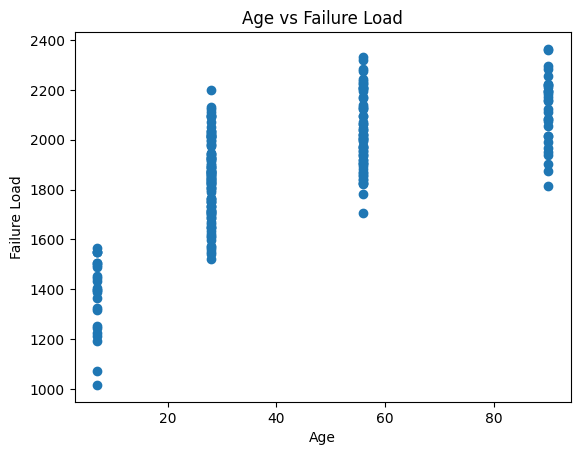

In [313]:
# Age vs Failure Load 
import matplotlib.pyplot as plt
plt.scatter(df["Age_Days"], df["Failure_Load_kN"]) 
plt.xlabel("Age") 
plt.ylabel("Failure Load") 
plt.title("Age vs Failure Load") 
plt.show()

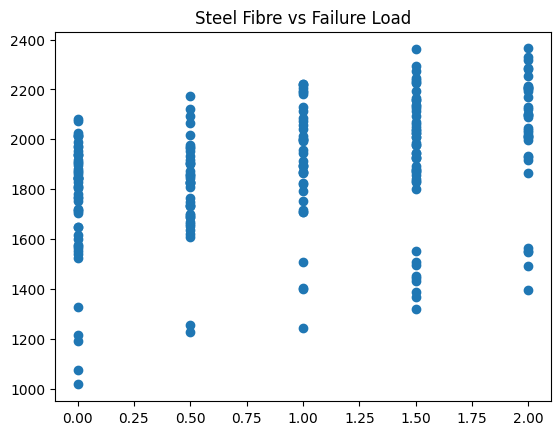

In [314]:
# Steel Fibre vs Load 
plt.scatter(df["Steel_Fibre_%"], df["Failure_Load_kN"]) 
plt.title("Steel Fibre vs Failure Load") 
plt.show()

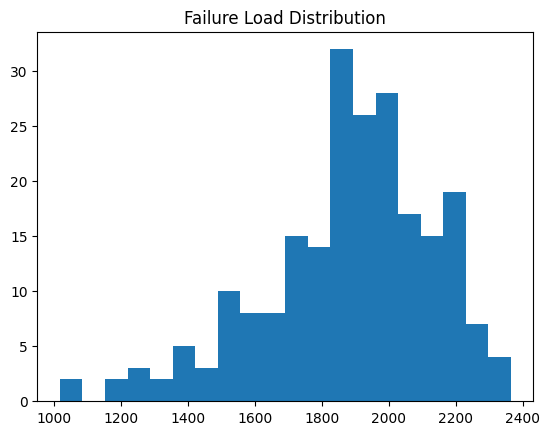

In [315]:
# Distribution 
plt.hist(df["Failure_Load_kN"], bins=20) 
plt.title("Failure Load Distribution") 
plt.show()

In [316]:
print(list(df.columns))

['Mix_ID', 'Steel_Fibre_%', 'Cement_kg_m3', 'Sand_kg_m3', 'Water_kg_m3', 'SilicaFume_kg_m3', 'Age_Days', 'Curing_Method', 'Failure_Load_kN']


In [317]:
# Feature engineering
df["Water_Cement_Ratio"] = df["Water_kg_m3"] / (df["Cement_kg_m3"] + 1e-6)

# df["Binder_Content"] = df["Cement_kg_m3"] + df["SilicaFume_kg_m3"]

# df["Fibre_Age"] = df["Steel_Fibre_%"] * df["Age_Days"]

# df["Log_Age"] = np.log1p(df["Age_Days"])

# df["Sand_Binder_Ratio"] = df["Sand_kg_m3"] / (df["Binder_Content"] + 1e-6)

In [341]:
df

,Mix_ID,Steel_Fibre_%,Cement_kg_m3,Sand_kg_m3,Water_kg_m3,SilicaFume_kg_m3,Age_Days,Curing_Method,Failure_Load_kN,Water_Cement_Ratio
0,UHPC-4,1.5,880,1035,168,190,28,Ambient Curing,1798.7,0.190909
1,UHPC-2,0.5,840,1065,172,170,28,Steam Curing,1734.3,0.204762
2,UHPC-1,0.0,820,1080,175,160,28,Heat Curing,1807.1,0.213415
3,UHPC-4,1.5,880,1035,168,190,28,Heat Curing,2024.2,0.190909
4,UHPC-3,1.0,860,1050,170,180,56,Steam Curing,2001.7,0.197674
...,...,...,...,...,...,...,...,...,...,...
215,UHPC-5,2.0,900,1020,165,200,90,Ambient Curing,2283.6,0.183333
216,UHPC-4,1.5,880,1035,168,190,28,Steam Curing,1975.2,0.190909
217,UHPC-4,1.5,880,1035,168,190,56,Heat Curing,2229.3,0.190909
218,UHPC-3,1.0,860,1050,170,180,56,Ambient Curing,1994.9,0.197674


In [ ]:
# Split
from sklearn.model_selection import train_test_split 

# X = df.drop(["Failure_Load_kN", "Mix_ID"], axis=1)
X = df[[
    "Steel_Fibre_%",
    "Water_Cement_Ratio",
    "Age_Days",
    "Curing_Method"
]]
y = df["Failure_Load_kN"] 

# Encoding
X = pd.get_dummies(X) 
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [319]:
from xgboost import XGBRegressor 

model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=2,
    random_state=42
)

In [345]:
# Train model
model.fit(X_train, y_train) 
from sklearn.metrics import r2_score 

# Test model
y_pred = model.predict(X_test) 

# Evaluate model
print("Train R2:", model.score(X_train, y_train))
print("Test R2:", r2_score(y_test, y_pred))

Train R2: 0.9819606434189858
Test R2: 0.9549770277553659


In [348]:
y_pred

array([2061.2625, 1874.5701, 1797.2123, 1879.0271, 1826.1   , 2010.6138,
       1488.8357, 1397.6567, 1869.896 , 1894.3386, 1747.3927, 1656.7972,
       1398.2192, 1817.344 , 1777.1354, 1972.7369, 1826.1   , 1954.2458,
       1747.3927, 1929.205 , 1220.2745, 1735.5045, 2115.6294, 1894.3386,
       1874.5701, 1997.9504, 1593.4474, 1882.1436, 2234.455 , 2153.6785,
       2119.69  , 1443.2147, 1874.5701, 1882.1436, 1658.2294, 1946.2217,
       1791.5482, 2293.7139, 2065.0745, 2010.6138, 1882.1436, 2106.8647,
       1874.5701, 2234.455 ], dtype=float32)

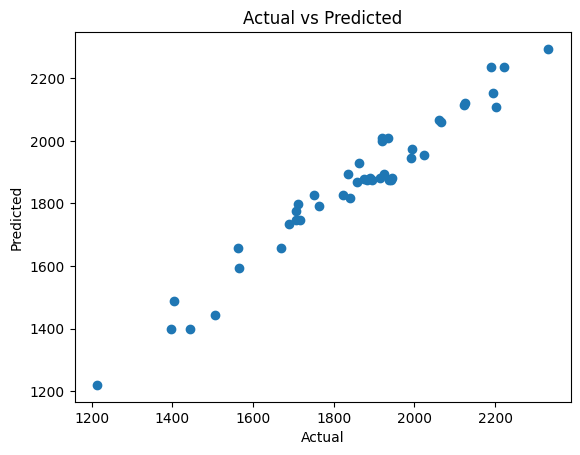

In [321]:
# visual prediction
plt.scatter(y_test, y_pred) 
plt.xlabel("Actual") 
plt.ylabel("Predicted") 
plt.title("Actual vs Predicted") 
plt.show()

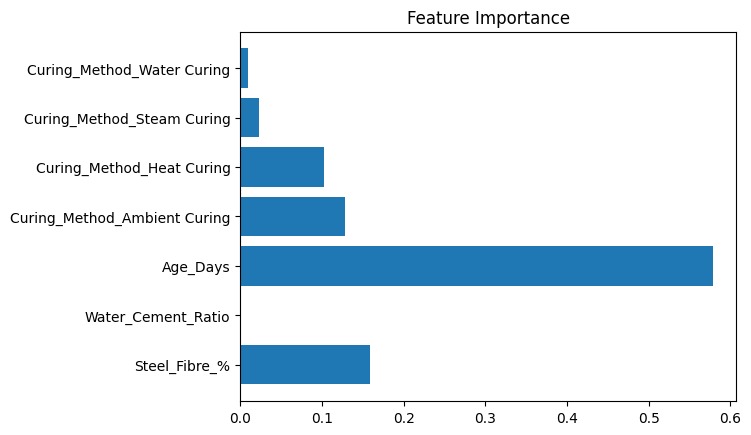

In [322]:
# Feature Importance
importances = model.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

In [323]:
# Manual Check
print("Test 1:", model.predict(X_test.iloc[[0]])) 
print("Test 2:", model.predict(X_test.iloc[[5]])) 
print("Test 3:", model.predict(X_test.iloc[[10]])) 
print("Test 4:", model.predict(X_test.iloc[[20]]))

Test 1: [2061.2625]
Test 2: [2010.6138]
Test 3: [1747.3927]
Test 4: [1220.2745]


In [ ]:
X_test

,Steel_Fibre_%,Water_Cement_Ratio,Age_Days,Curing_Method_Ambient Curing,Curing_Method_Heat Curing,Curing_Method_Steam Curing,Curing_Method_Water Curing
132,0.5,0.204762,56,False,True,False,False
148,0.0,0.213415,56,False,False,True,False
93,0.0,0.213415,28,False,True,False,False
180,0.0,0.213415,90,True,False,False,False
15,1.0,0.197674,28,False,False,False,True
115,2.0,0.183333,28,False,False,False,True
172,1.0,0.197674,7,False,True,False,False
209,1.5,0.190909,7,False,False,False,True
75,0.5,0.204762,28,False,True,False,False
142,1.5,0.190909,28,False,False,False,True


In [336]:
sample

,Steel_Fibre_%,Water_Cement_Ratio,Age_Days,Curing_Method_Ambient Curing,Curing_Method_Heat Curing,Curing_Method_Steam Curing,Curing_Method_Water Curing
132,0.5,0.204762,56,False,True,False,False


In [337]:
sample2

,Steel_Fibre_%,Water_Cement_Ratio,Age_Days,Curing_Method_Ambient Curing,Curing_Method_Heat Curing,Curing_Method_Steam Curing,Curing_Method_Water Curing
132,0.5,20.204762,56,False,True,False,False


In [350]:
sample = X_test.iloc[[0]].copy()
sample2 = sample.copy()

# Change something meaningful
sample2["Water_Cement_Ratio"] += 0.7

print("Before:", model.predict(sample))
print("After :", model.predict(sample2))

Before: [2061.2625]
After : [2061.2625]


In [351]:
sample

,Steel_Fibre_%,Water_Cement_Ratio,Age_Days,Curing_Method_Ambient Curing,Curing_Method_Heat Curing,Curing_Method_Steam Curing,Curing_Method_Water Curing
132,0.5,0.204762,56,False,True,False,False


In [352]:
sample2

,Steel_Fibre_%,Water_Cement_Ratio,Age_Days,Curing_Method_Ambient Curing,Curing_Method_Heat Curing,Curing_Method_Steam Curing,Curing_Method_Water Curing
132,0.5,0.904762,56,False,True,False,False


In [339]:
for i in range(10):
    print(model.predict(X_test.iloc[[i]]))

[2061.2625]
[1874.5701]
[1797.2123]
[1879.0271]
[1826.1]
[2010.6138]
[1488.8357]
[1397.6567]
[1869.896]
[1894.3386]


In [330]:
print(X.columns)

Index(['Steel_Fibre_%', 'Water_Cement_Ratio', 'Age_Days',
       'Curing_Method_Ambient Curing', 'Curing_Method_Heat Curing',
       'Curing_Method_Steam Curing', 'Curing_Method_Water Curing'],
      dtype='str')


In [331]:
print(df.shape)

(220, 10)


In [332]:
print(df.describe())

       Steel_Fibre_%  Cement_kg_m3   Sand_kg_m3  Water_kg_m3  \
count     220.000000    220.000000   220.000000   220.000000   
mean        0.947727    857.909091  1051.568182   170.286364   
std         0.714011     28.560453    21.420340     3.431628   
min         0.000000    820.000000  1020.000000   165.000000   
25%         0.500000    840.000000  1035.000000   168.000000   
50%         1.000000    860.000000  1050.000000   170.000000   
75%         1.500000    880.000000  1065.000000   172.000000   
max         2.000000    900.000000  1080.000000   175.000000   

       SilicaFume_kg_m3    Age_Days  Failure_Load_kN  Water_Cement_Ratio  
count        220.000000  220.000000       220.000000          220.000000  
mean         178.954545   42.240909      1881.377727            0.198841  
std           14.280226   24.752679       257.788538            0.010615  
min          160.000000    7.000000      1016.400000            0.183333  
25%          170.000000   28.000000      1745.32

In [333]:
# Saving model

joblib.dump(model, "../model/model.pkl") 
joblib.dump(X.columns, "../model/columns.pkl")


['../model/columns.pkl']